# Brain Tumor MRI Classification — v1 fidèle simplifié

Version fidèle au notebook v1, en gardant :
- dataset binaire
- transforms albumentations
- EfficientNet-B0
- Phase A / Phase B
- TTA
- threshold = 0.3
- métriques + matrices de confusion
- checkpoints pour déploiement

Les sections de visualisation / exploration ont été retirées.


In [1]:
# Installation
!pip install -q torch torchvision torchaudio scikit-learn matplotlib seaborn kagglehub albumentations tqdm


In [2]:
# Imports et configuration
import os
import random
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)
from tqdm.auto import tqdm

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
sns.set_palette("husl")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Seed:", SEED)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))


Seed: 42
Device: cuda
GPU: Tesla T4


In [3]:
# Dataset Kaggle
TRAIN_DIR = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training"
TEST_DIR  = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing"

print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR :", TEST_DIR)
print("Train folders:", os.listdir(TRAIN_DIR))
print("Test folders :", os.listdir(TEST_DIR))


TRAIN_DIR: /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training
TEST_DIR : /kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing
Train folders: ['no_tumor', 'pituitary_tumor', 'meningioma_tumor', 'glioma_tumor']
Test folders : ['no_tumor', 'pituitary_tumor', 'meningioma_tumor', 'glioma_tumor']


In [4]:
# Dataset binaire compatible albumentations
IMG_EXTS = {".jpg", ".jpeg", ".png"}

class BrainMRIDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        if not self.root_dir.exists():
            raise FileNotFoundError(f"Dossier introuvable : {self.root_dir}")

        for cls_dir in sorted(self.root_dir.iterdir()):
            if not cls_dir.is_dir():
                continue

            label = 0 if cls_dir.name == "no_tumor" else 1

            for img_path in sorted(cls_dir.iterdir()):
                if img_path.suffix.lower() in IMG_EXTS:
                    self.samples.append((img_path, label))

        if not self.samples:
            raise ValueError(f"Aucune image trouvée dans {self.root_dir}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image_np = np.array(Image.open(img_path).convert("RGB"))

        if self.transform is not None:
            image = self.transform(image=image_np)["image"]
        else:
            image = image_np

        label = torch.tensor(label, dtype=torch.long)
        return image, label

full_dataset = BrainMRIDataset(root_dir=TRAIN_DIR, transform=None)
labels_all = [full_dataset.samples[i][1] for i in range(len(full_dataset))]
counts = Counter(labels_all)
print("Dataset chargé:", len(full_dataset), "images")
print("Classe 0 (sain)  :", counts[0], "images")
print("Classe 1 (tumeur):", counts[1], "images")


Dataset chargé: 2870 images
Classe 0 (sain)  : 395 images
Classe 1 (tumeur): 2475 images


In [5]:
# Transforms albumentations
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
IMG_SIZE = 224

def get_train_transforms(augmentation_level="standard"):
    if augmentation_level == "standard":
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.Rotate(limit=10, p=0.5),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.3),
            A.Rotate(limit=12, p=0.5),
            A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=10, p=0.3),
            A.CLAHE(clip_limit=2.0, p=0.4),
            A.RandomBrightnessContrast(brightness_limit=0.10, contrast_limit=0.10, p=0.4),
            A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
            A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ])

def get_eval_transforms():
    return A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ToTensorV2(),
    ])

def get_tta_transforms():
    return [
        get_eval_transforms(),
        A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.HorizontalFlip(p=1.0),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.VerticalFlip(p=1.0),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Rotate(limit=(10, 10), p=1.0),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]),
        A.Compose([
            A.Resize(IMG_SIZE, IMG_SIZE),
            A.Rotate(limit=(-10, -10), p=1.0),
            A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
            ToTensorV2(),
        ]),
    ]

print("Transforms définis.")
print("TTA:", len(get_tta_transforms()), "versions")


Transforms définis.
TTA: 5 versions


In [6]:
# Split train / val et DataLoaders
idx_all = np.arange(len(labels_all))
train_idx, val_idx = train_test_split(
    idx_all,
    test_size=0.2,
    random_state=SEED,
    stratify=labels_all,
)

train_labels = [labels_all[i] for i in train_idx]
val_labels = [labels_all[i] for i in val_idx]

print("Train:", len(train_idx), "images —", Counter(train_labels))
print("Val  :", len(val_idx), "images —", Counter(val_labels))

BATCH_SIZE = 32
NUM_WORKERS = 0

train_dataset = BrainMRIDataset(root_dir=TRAIN_DIR, transform=get_train_transforms("standard"))
val_dataset = BrainMRIDataset(root_dir=TRAIN_DIR, transform=get_eval_transforms())

train_set = Subset(train_dataset, train_idx)
val_set = Subset(val_dataset, val_idx)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)

val_loader = DataLoader(
    val_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)

print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))


Train: 2296 images — Counter({1: 1980, 0: 316})
Val  : 574 images — Counter({1: 495, 0: 79})
Train batches: 72
Val batches  : 18


In [7]:
# EfficientNet-B0
def build_model(num_classes=2, pretrained=True):
    weights = EfficientNet_B0_Weights.DEFAULT if pretrained else None
    try:
        model = efficientnet_b0(weights=weights)
        print("EfficientNet-B0 chargé.")
    except Exception as e:
        print("Pré-entraînement indisponible, fallback sans poids:", e)
        model = efficientnet_b0(weights=None)

    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(in_features, num_classes),
    )
    return model

def freeze_backbone(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.classifier.parameters():
        p.requires_grad = True
    return model

def unfreeze_last_blocks(model):
    for p in model.parameters():
        p.requires_grad = False
    for p in model.features[6].parameters():
        p.requires_grad = True
    for p in model.features[7].parameters():
        p.requires_grad = True
    for p in model.features[8].parameters():
        p.requires_grad = True
    for p in model.classifier.parameters():
        p.requires_grad = True
    return model

model = build_model(num_classes=2, pretrained=True).to(DEVICE)
print("Paramètres totaux:", sum(p.numel() for p in model.parameters()))


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s]


EfficientNet-B0 chargé.
Paramètres totaux: 4010110


In [8]:
# Engine, TTA, métriques et utilitaires
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, n_samples, correct = 0.0, 0, 0
    all_preds, all_targets = [], []

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        n_samples += images.size(0)

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(labels.cpu().tolist())

    return {
        "loss": running_loss / n_samples,
        "acc": correct / n_samples,
        "preds": all_preds,
        "targets": all_targets,
    }

@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, n_samples, correct = 0.0, 0, 0
    all_preds, all_targets, all_probs = [], [], []

    for images, labels in tqdm(loader, desc="Val", leave=False):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        n_samples += images.size(0)

        probs = torch.softmax(outputs, dim=1)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        all_preds.extend(preds.cpu().tolist())
        all_targets.extend(labels.cpu().tolist())
        all_probs.extend(probs[:, 1].cpu().tolist())

    return {
        "loss": running_loss / n_samples,
        "acc": correct / n_samples,
        "preds": all_preds,
        "targets": all_targets,
        "probs": all_probs,
    }

@torch.no_grad()
def predict_tta(model, dataset, device, tta_transforms=None):
    if tta_transforms is None:
        tta_transforms = get_tta_transforms()

    model.eval()
    all_probs = []
    all_targets = []

    for idx in tqdm(range(len(dataset)), desc="TTA", leave=False):
        if hasattr(dataset, "indices"):
            img_path, label = dataset.dataset.samples[dataset.indices[idx]]
        else:
            img_path, label = dataset.samples[idx]

        image_np = np.array(Image.open(img_path).convert("RGB"))
        probs_per_version = []

        for t in tta_transforms:
            img_t = t(image=image_np)["image"].unsqueeze(0).to(device)
            output = model(img_t)
            prob = torch.softmax(output, dim=1)[0, 1].item()
            probs_per_version.append(prob)

        avg_prob = np.mean(probs_per_version)
        all_probs.append(avg_prob)
        all_targets.append(label)

    return {"probs": all_probs, "targets": all_targets}

def predict_with_threshold(probs, threshold=0.3):
    return [1 if p >= threshold else 0 for p in probs]

def save_checkpoint(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)
    print(f"✅ Modèle sauvegardé : {path}")

def load_checkpoint(model, path, map_location=None):
    state_dict = torch.load(path, map_location=map_location)
    model.load_state_dict(state_dict)
    return model

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
        "report": classification_report(y_true, y_pred, zero_division=0, digits=4),
    }

THRESHOLD = 0.3
print("Seuil TTA:", THRESHOLD)


Seuil TTA: 0.3


In [9]:
# Phase A — Backbone gelé
model = freeze_backbone(model)

class_weights = torch.tensor([2475 / 395, 1.0]).to(DEVICE)
criterion_train = nn.CrossEntropyLoss(weight=class_weights)
criterion_eval = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)
EPOCHS_A = 15
PATIENCE_A = 3
scheduler_a = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_A)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss = float("inf")
patience_counter = 0

print("Loss pondérée sain =", class_weights[0].item())
print("Params entraînables Phase A =", sum(p.numel() for p in model.parameters() if p.requires_grad))

for epoch in range(EPOCHS_A):
    current_lr = optimizer.param_groups[0]["lr"]
    train_r = train_one_epoch(model, train_loader, criterion_train, optimizer, DEVICE)
    val_r = validate_one_epoch(model, val_loader, criterion_eval, DEVICE)
    scheduler_a.step()

    history["train_loss"].append(train_r["loss"])
    history["val_loss"].append(val_r["loss"])
    history["train_acc"].append(train_r["acc"])
    history["val_acc"].append(val_r["acc"])

    if val_r["loss"] < best_val_loss:
        best_val_loss = val_r["loss"]
        patience_counter = 0
        save_checkpoint(model, "artifacts/checkpoints/efficientnet_phase_a.pt")
        marker = "✅ BEST"
    else:
        patience_counter += 1
        marker = f"(patience {patience_counter}/{PATIENCE_A})"

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS_A} | LR: {current_lr:.6f} | "
        f"Train Loss: {train_r['loss']:.4f} Acc: {train_r['acc']:.4f} | "
        f"Val Loss: {val_r['loss']:.4f} Acc: {val_r['acc']:.4f} {marker}"
    )

    if patience_counter >= PATIENCE_A:
        print("⏹ Early stopping Phase A")
        break

actual_epochs_a = len(history["train_loss"])
print("Phase A terminée. Epochs:", actual_epochs_a)


Loss pondérée sain = 6.265822887420654
Params entraînables Phase A = 2562


Train:   0%|          | 0/72 [00:00<?, ?it/s]

Val:   0%|          | 0/18 [00:00<?, ?it/s]

✅ Modèle sauvegardé : artifacts/checkpoints/efficientnet_phase_a.pt
Epoch 01/15 | LR: 0.001000 | Train Loss: 0.3399 Acc: 0.9033 | Val Loss: 0.2323 Acc: 0.9077 ✅ BEST


Train:   0%|          | 0/72 [00:00<?, ?it/s]

...

Val:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 08/15 | LR: 0.000552 | Train Loss: 0.1284 Acc: 0.9517 | Val Loss: 0.1317 Acc: 0.9599 (patience 2/3)


Train:   0%|          | 0/72 [00:00<?, ?it/s]

Val:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 09/15 | LR: 0.000448 | Train Loss: 0.1331 Acc: 0.9538 | Val Loss: 0.1464 Acc: 0.9582 (patience 3/3)
⏹ Early stopping Phase A
Phase A terminée. Epochs: 9


In [10]:
# Phase B — Fine-tuning
model = build_model(num_classes=2, pretrained=False).to(DEVICE)
model = load_checkpoint(model, "artifacts/checkpoints/efficientnet_phase_a.pt", map_location=DEVICE)
model = unfreeze_last_blocks(model)

optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
EPOCHS_B = 25
PATIENCE_B = 5
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS_B)

train_dataset.transform = get_train_transforms("advanced")

best_val_loss_b = float("inf")
best_val_acc = 0.0
patience_counter = 0

print("Params entraînables Phase B =", sum(p.numel() for p in model.parameters() if p.requires_grad))

for epoch in range(EPOCHS_B):
    current_lr = optimizer.param_groups[0]["lr"]
    train_r = train_one_epoch(model, train_loader, criterion_train, optimizer, DEVICE)
    val_r = validate_one_epoch(model, val_loader, criterion_eval, DEVICE)
    scheduler_b.step()

    history["train_loss"].append(train_r["loss"])
    history["val_loss"].append(val_r["loss"])
    history["train_acc"].append(train_r["acc"])
    history["val_acc"].append(val_r["acc"])

    if val_r["loss"] < best_val_loss_b:
        best_val_loss_b = val_r["loss"]
        patience_counter = 0
        save_checkpoint(model, "artifacts/checkpoints/efficientnet_best.pt")
        marker = "✅ BEST"
    else:
        patience_counter += 1
        marker = f"(patience {patience_counter}/{PATIENCE_B})"

    if val_r["acc"] > best_val_acc:
        best_val_acc = val_r["acc"]

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS_B} | LR: {current_lr:.6f} | "
        f"Train Loss: {train_r['loss']:.4f} Acc: {train_r['acc']:.4f} | "
        f"Val Loss: {val_r['loss']:.4f} Acc: {val_r['acc']:.4f} {marker}"
    )

    if patience_counter >= PATIENCE_B:
        print("⏹ Early stopping Phase B")
        break

actual_epochs_b = len(history["train_loss"]) - actual_epochs_a
print("Phase B terminée. Epochs:", actual_epochs_b, "| Best val acc:", best_val_acc)


EfficientNet-B0 chargé.
Params entraînables Phase B = 3158302


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_55/3012048067.py:24: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 25.0), p=0.2),
/tmp/ipykernel_55/3012048067.py:25: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=20, max_width=20, p=0.3),


Train:   0%|          | 0/72 [00:00<?, ?it/s]

Val:   0%|          | 0/18 [00:00<?, ?it/s]

✅ Modèle sauvegardé : artifacts/checkpoints/efficientnet_best.pt
Epoch 01/25 | LR: 0.000100 | Train Loss: 0.2912 Acc: 0.8767 | Val Loss: 0.0937 Acc: 0.9686 ✅ BEST


...

Val:   0%|          | 0/18 [00:00<?, ?it/s]

Epoch 24/25 | LR: 0.000002 | Train Loss: 0.0565 Acc: 0.9795 | Val Loss: 0.0130 Acc: 0.9983 (patience 2/5)


Train:   0%|          | 0/72 [00:00<?, ?it/s]

Val:   0%|          | 0/18 [00:00<?, ?it/s]

✅ Modèle sauvegardé : artifacts/checkpoints/efficientnet_best.pt
Epoch 25/25 | LR: 0.000000 | Train Loss: 0.0613 Acc: 0.9730 | Val Loss: 0.0105 Acc: 0.9965 ✅ BEST
Phase B terminée. Epochs: 25 | Best val acc: 0.9982578397212544


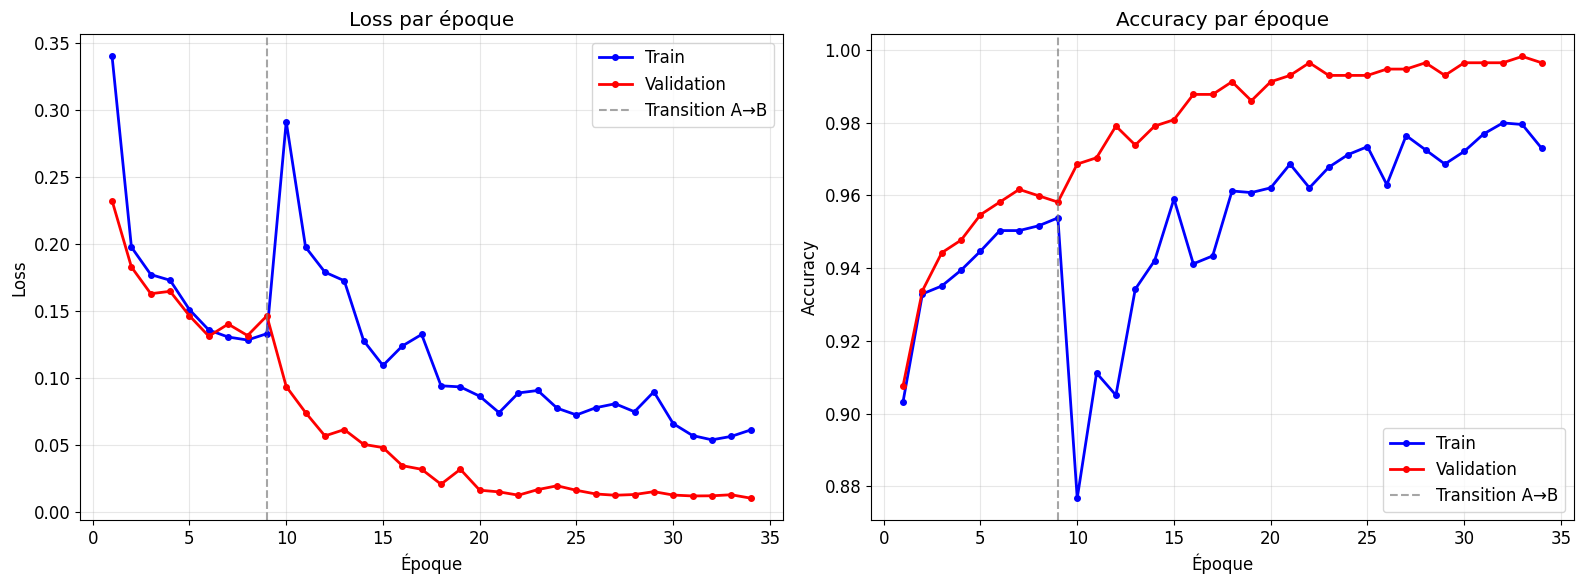

In [11]:
# Courbes d'entraînement
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(epochs_range, history["train_loss"], "b-o", label="Train", linewidth=2, markersize=4)
ax1.plot(epochs_range, history["val_loss"], "r-o", label="Validation", linewidth=2, markersize=4)
ax1.axvline(x=actual_epochs_a, color="gray", linestyle="--", alpha=0.7, label="Transition A→B")
ax1.set_title("Loss par époque")
ax1.set_xlabel("Époque")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, history["train_acc"], "b-o", label="Train", linewidth=2, markersize=4)
ax2.plot(epochs_range, history["val_acc"], "r-o", label="Validation", linewidth=2, markersize=4)
ax2.axvline(x=actual_epochs_a, color="gray", linestyle="--", alpha=0.7, label="Transition A→B")
ax2.set_title("Accuracy par époque")
ax2.set_xlabel("Époque")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [12]:
# Validation — Standard vs TTA
best_model = build_model(num_classes=2, pretrained=False).to(DEVICE)
best_model = load_checkpoint(best_model, "artifacts/checkpoints/efficientnet_best.pt", map_location=DEVICE)

val_result = validate_one_epoch(best_model, val_loader, criterion_eval, DEVICE)
val_tta = predict_tta(best_model, val_set, DEVICE)

pred_std050 = predict_with_threshold(val_result["probs"], threshold=0.5)
pred_std030 = predict_with_threshold(val_result["probs"], threshold=THRESHOLD)
pred_tta030 = predict_with_threshold(val_tta["probs"], threshold=THRESHOLD)

m_std050 = compute_metrics(val_result["targets"], pred_std050)
m_std030 = compute_metrics(val_result["targets"], pred_std030)
m_tta030 = compute_metrics(val_tta["targets"], pred_tta030)

print("=== COMPARAISON VALIDATION ===")
print("Std 0.5 | acc={:.4f} precision={:.4f} recall={:.4f} f1={:.4f}".format(
    m_std050["accuracy"], m_std050["precision"], m_std050["recall"], m_std050["f1"]
))
print("Std 0.3 | acc={:.4f} precision={:.4f} recall={:.4f} f1={:.4f}".format(
    m_std030["accuracy"], m_std030["precision"], m_std030["recall"], m_std030["f1"]
))
print("TTA 0.3 | acc={:.4f} precision={:.4f} recall={:.4f} f1={:.4f}".format(
    m_tta030["accuracy"], m_tta030["precision"], m_tta030["recall"], m_tta030["f1"]
))

print("\nRapport TTA validation seuil 0.3")
print(m_tta030["report"])


EfficientNet-B0 chargé.


Val:   0%|          | 0/18 [00:00<?, ?it/s]

TTA:   0%|          | 0/574 [00:00<?, ?it/s]

=== COMPARAISON VALIDATION ===
Std 0.5 | acc=0.9965 precision=1.0000 recall=0.9960 f1=0.9980
Std 0.3 | acc=0.9965 precision=0.9980 recall=0.9980 f1=0.9980
TTA 0.3 | acc=0.9965 precision=0.9960 recall=1.0000 f1=0.9980

Rapport TTA validation seuil 0.3
              precision    recall  f1-score   support

           0     1.0000    0.9747    0.9872        79
           1     0.9960    1.0000    0.9980       495

    accuracy                         0.9965       574
   macro avg     0.9980    0.9873    0.9926       574
weighted avg     0.9965    0.9965    0.9965       574



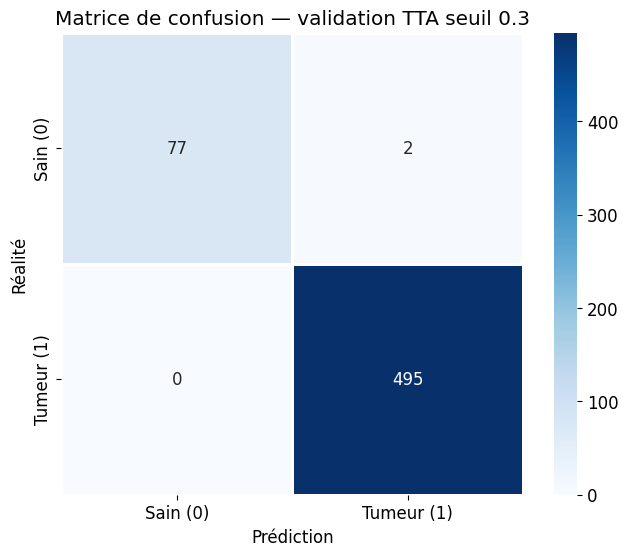

TN = 77 | FP = 2 | FN = 0 | TP = 495


In [13]:
# Matrice de confusion validation (TTA seuil 0.3)
cm = m_tta030["confusion_matrix"]

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    linewidths=1,
    xticklabels=["Sain (0)", "Tumeur (1)"],
    yticklabels=["Sain (0)", "Tumeur (1)"],
    ax=ax,
)
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
ax.set_title("Matrice de confusion — validation TTA seuil 0.3")
plt.show()

tn, fp, fn, tp = cm.ravel()
print("TN =", tn, "| FP =", fp, "| FN =", fn, "| TP =", tp)


In [14]:
# Test final
test_dataset = BrainMRIDataset(root_dir=TEST_DIR, transform=get_eval_transforms())
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=DEVICE.type == "cuda",
)

test_labels = [test_dataset.samples[i][1] for i in range(len(test_dataset))]
print("Test size:", len(test_dataset))
print("Test distribution:", Counter(test_labels))

std_test = validate_one_epoch(best_model, test_loader, criterion_eval, DEVICE)
tta_test = predict_tta(best_model, test_dataset, DEVICE)

t_std050 = predict_with_threshold(std_test["probs"], threshold=0.5)
t_std030 = predict_with_threshold(std_test["probs"], threshold=THRESHOLD)
t_tta030 = predict_with_threshold(tta_test["probs"], threshold=THRESHOLD)

tm_std050 = compute_metrics(std_test["targets"], t_std050)
tm_std030 = compute_metrics(std_test["targets"], t_std030)
tm_tta030 = compute_metrics(tta_test["targets"], t_tta030)

print("=== RÉSULTATS TEST FINAL ===")
print("Std 0.5 | acc={:.4f} precision={:.4f} recall={:.4f} f1={:.4f}".format(
    tm_std050["accuracy"], tm_std050["precision"], tm_std050["recall"], tm_std050["f1"]
))
print("Std 0.3 | acc={:.4f} precision={:.4f} recall={:.4f} f1={:.4f}".format(
    tm_std030["accuracy"], tm_std030["precision"], tm_std030["recall"], tm_std030["f1"]
))
print("TTA 0.3 | acc={:.4f} precision={:.4f} recall={:.4f} f1={:.4f}".format(
    tm_tta030["accuracy"], tm_tta030["precision"], tm_tta030["recall"], tm_tta030["f1"]
))

print("\nRapport test TTA seuil 0.3")
print(tm_tta030["report"])


Test size: 394
Test distribution: Counter({1: 289, 0: 105})


Val:   0%|          | 0/13 [00:00<?, ?it/s]

TTA:   0%|          | 0/394 [00:00<?, ?it/s]

=== RÉSULTATS TEST FINAL ===
Std 0.5 | acc=0.9010 precision=1.0000 recall=0.8651 f1=0.9276
Std 0.3 | acc=0.9188 precision=1.0000 recall=0.8893 f1=0.9414
TTA 0.3 | acc=0.9391 precision=1.0000 recall=0.9170 f1=0.9567

Rapport test TTA seuil 0.3
              precision    recall  f1-score   support

           0     0.8140    1.0000    0.8974       105
           1     1.0000    0.9170    0.9567       289

    accuracy                         0.9391       394
   macro avg     0.9070    0.9585    0.9271       394
weighted avg     0.9504    0.9391    0.9409       394



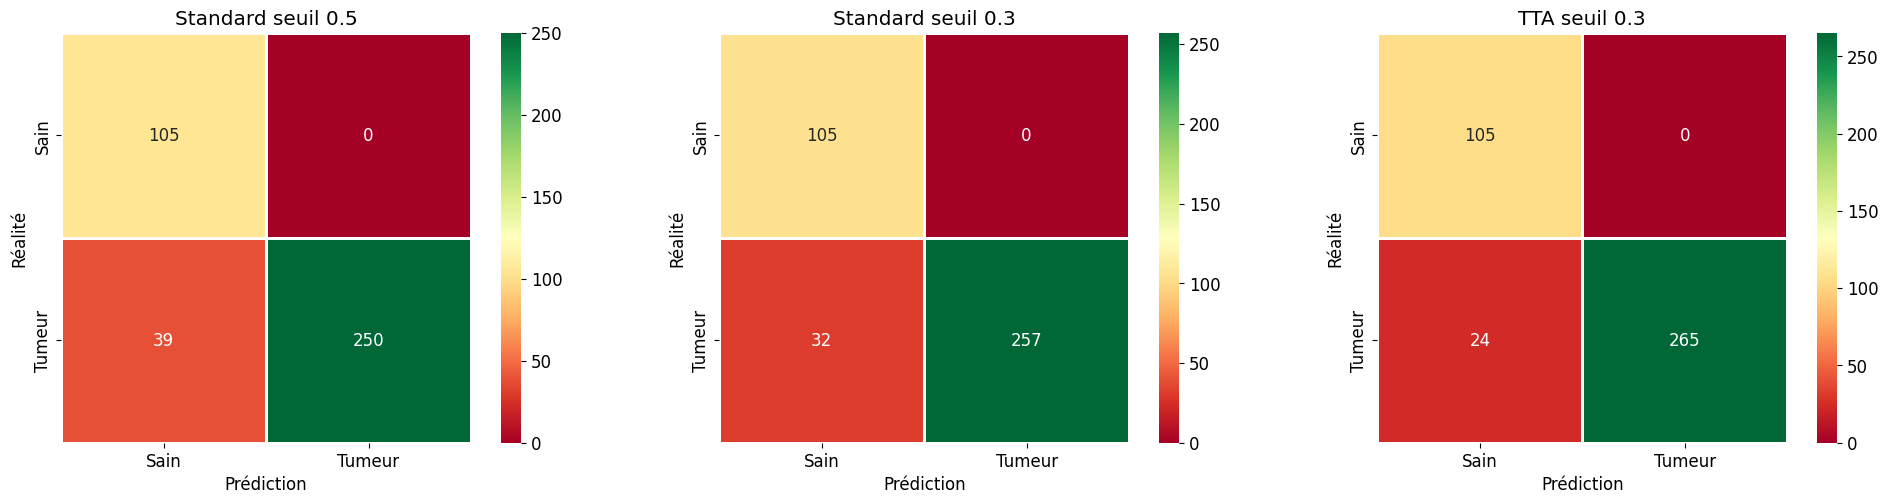

=== TTA seuil 0.3 ===
Tumeurs détectées : 265 / 289
Tumeurs ratées    : 24
Faux positifs     : 0
Test set          : 394


In [15]:
# Matrices de confusion test
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (title, metrics_dict) in zip(
    axes,
    [
        ("Standard seuil 0.5", tm_std050),
        ("Standard seuil 0.3", tm_std030),
        ("TTA seuil 0.3", tm_tta030),
    ],
):
    sns.heatmap(
        metrics_dict["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="RdYlGn",
        square=True,
        linewidths=1,
        xticklabels=["Sain", "Tumeur"],
        yticklabels=["Sain", "Tumeur"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Réalité")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = tm_tta030["confusion_matrix"].ravel()
print("=== TTA seuil 0.3 ===")
print("Tumeurs détectées :", tp, "/", tp + fn)
print("Tumeurs ratées    :", fn)
print("Faux positifs     :", fp)
print("Test set          :", len(test_dataset))


In [16]:
# Checkpoint final pour déploiement
final_ckpt = Path("artifacts/checkpoints/best_efficientnet_b0.pt")
save_checkpoint(best_model, final_ckpt)
print("Checkpoint final prêt pour le déploiement :", final_ckpt.resolve())
print("Fichiers présents dans artifacts/checkpoints:")
print(os.listdir("artifacts/checkpoints"))


✅ Modèle sauvegardé : artifacts/checkpoints/best_efficientnet_b0.pt
Checkpoint final prêt pour le déploiement : /kaggle/working/artifacts/checkpoints/best_efficientnet_b0.pt
Fichiers présents dans artifacts/checkpoints:
['best_efficientnet_b0.pt', 'efficientnet_phase_a.pt', 'efficientnet_best.pt']
